En este segundo notebook construí una línea base para la clasificación de informes mamográficos. El objetivo fue transformar el texto clínico en vectores TF-IDF y entrenar un clasificador lineal, con el fin de obtener una referencia inicial del desempeño del sistema antes de probar modelos más complejos.

# Parte 2 - Preparación del dataset para transformers

En esta sección se carga el archivo procesado del proyecto y se revisa su estructura general.  
El objetivo es confirmar que las columnas necesarias para el entrenamiento están disponibles, especialmente el texto limpio del informe y la etiqueta BI-RADS.



Primero cargo el dataset limpio y separa variables:

In [26]:
# Importamos pandas para trabajar con tablas y archivos CSV
import pandas as pd

# Definimos la ruta del archivo procesado
# Ajusta esta ruta según la ubicación real dentro de tu proyecto
ruta_archivo = "../data/processed/reports_cleaned.csv"

# Cargamos el dataset en un DataFrame
df = pd.read_csv(ruta_archivo)

# Mostramos las primeras filas para verificar que el archivo se cargó bien
df.head()

,Full_Report,Conclusion,Recommendations,BI-RADS,Full_Report_clean,Conclusion_clean,Recommendations_clean,len_report
0,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- MAMAS CON ÁREAS DENSAS.-\n- IMAGEN NODULAR D...,- SE SUGIERE ECOGRAFÍA MAMARIA Y CORRELACIÓN C...,0,mamografia digital bilateral craneo-caudal y m...,- mamas con areas densas.- - imagen nodular de...,- se sugiere ecografia mamaria y correlacion c...,938
1,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- MAMAS DENSAS.\n- CALCIFICACIONES CON CARACTE...,- SE SUGIERE CORRELACIÓN CON ECOGRAFÍA MAMARIA...,2,mamografia digital bilateral craneo-caudal y m...,- mamas densas. - calcificaciones con caracter...,- se sugiere correlacion con ecografia mamaria...,607
2,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- IMAGEN NODULAR DE NATURALEZA A DETERMINAR EN...,- SE SUGIERE CORRELACIÓN CON ECOGRAFÍA MAMARIA...,0,mamografia digital bilateral craneo-caudal y m...,- imagen nodular de naturaleza a determinar en...,- se sugiere correlacion con ecografia mamaria...,1060
3,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- MAMOGRAFÍA DENTRO DE LOS PARÁMETROS NORMALES...,- SE SUGIERE CONTROL ANUAL.,1,mamografia digital bilateral craneo-caudal y m...,- mamografia dentro de los parametros normales...,- se sugiere control anual.,490
4,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- MAMAS CON ÁREAS DENSAS.-\n- IMÁGENES NODULAR...,- SE SUGIERE ECOGRAFÍA MAMARIA PARA POSTERIOR ...,0,mamografia digital bilateral craneo-caudal y m...,- mamas con areas densas.- - imagenes nodulare...,- se sugiere ecografia mamaria para posterior ...,1220


La visualización de las primeras filas permite comprobar rápidamente si el archivo fue cargado correctamente y si las columnas relevantes están presentes.  
En particular, interesa verificar la existencia de las columnas de texto y de la variable objetivo.

## Inspección de estructura y calidad básica

Antes de entrenar un modelo transformer, es necesario revisar la estructura del dataset, los tipos de datos y la presencia de valores nulos.  
Esto ayuda a evitar errores posteriores durante la tokenización y el entrenamiento.

In [27]:
# Mostramos los nombres de las columnas del dataset
print("Columnas disponibles:")
print(df.columns.tolist())

# Mostramos información general del DataFrame:
# número de filas, tipo de dato por columna y cantidad de valores no nulos
print("\nResumen general del DataFrame:")
df.info()

# Contamos los valores nulos por columna para detectar posibles problemas
print("\nValores nulos por columna:")
print(df.isnull().sum())

Columnas disponibles:
['Full_Report', 'Conclusion', 'Recommendations', 'BI-RADS', 'Full_Report_clean', 'Conclusion_clean', 'Recommendations_clean', 'len_report']

Resumen general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4357 entries, 0 to 4356
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Full_Report            4357 non-null   object
 1   Conclusion             4357 non-null   object
 2   Recommendations        4357 non-null   object
 3   BI-RADS                4357 non-null   int64 
 4   Full_Report_clean      4357 non-null   object
 5   Conclusion_clean       4357 non-null   object
 6   Recommendations_clean  4347 non-null   object
 7   len_report             4357 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 272.4+ KB

Valores nulos por columna:
Full_Report               0
Conclusion                0
Recommendations           0
BI-RADS                   

## Revisión inicial del dataset

Se verificó la carga correcta del archivo `reports_cleaned.csv`, obteniendo un total de 4357 registros y 8 variables.  
Las columnas disponibles incluyen tanto el texto original como versiones limpias del informe, además de la etiqueta diagnóstica `BI-RADS` y la longitud de cada reporte.

La inspección mostró que las variables principales para el modelado no presentan valores nulos.  
En particular, `Full_Report_clean` y `BI-RADS` están completas en todos los casos, lo que permite avanzar a la preparación del conjunto de datos para clasificación supervisada.

Se observó además que la columna `Recommendations_clean` contiene 10 valores faltantes.  
Sin embargo, esto no afecta la siguiente etapa, ya que el modelo se entrenará usando como entrada principal el texto limpio del informe completo.

## Selección de variables para modelado

En esta sección se construye un subconjunto del dataset con las variables estrictamente necesarias para el entrenamiento del modelo.  
Se utilizará `Full_Report_clean` como texto de entrada y `BI-RADS` como variable objetivo.

In [28]:
# Seleccionamos solamente las columnas que usaremos en el modelo
# Full_Report_clean será el texto de entrada
# BI-RADS será la etiqueta que el modelo debe predecir
df_model = df[["Full_Report_clean", "BI-RADS"]].copy()

# Renombramos las columnas para usar nombres más estándar en NLP
# 'text' para el texto de entrada y 'label' para la clase
df_model.columns = ["text", "label"]

# Verificamos las primeras filas del nuevo DataFrame
df_model.head()

,text,label
0,mamografia digital bilateral craneo-caudal y m...,0
1,mamografia digital bilateral craneo-caudal y m...,2
2,mamografia digital bilateral craneo-caudal y m...,0
3,mamografia digital bilateral craneo-caudal y m...,1
4,mamografia digital bilateral craneo-caudal y m...,0


La creación de este subconjunto permite simplificar el flujo de trabajo y facilita la integración posterior con librerías de transformers.  
Además, el uso de nombres estándar como `text` y `label` mejora la legibilidad del notebook y reduce la probabilidad de errores en etapas posteriores.

## Verificación final antes del particionado

Antes de dividir el conjunto de datos, es necesario asegurar que las variables tengan el tipo de dato correcto y que no existan filas vacías en las columnas seleccionadas.  
Esto evita problemas durante la tokenización y el entrenamiento del modelo.

In [29]:
# Eliminamos filas con valores nulos en las columnas que sí vamos a usar
df_model = df_model.dropna(subset=["text", "label"])

# Convertimos la columna de texto a string por seguridad
df_model["text"] = df_model["text"].astype(str)

# Convertimos la etiqueta a entero
df_model["label"] = df_model["label"].astype(int)

# Mostramos el tamaño final del DataFrame listo para modelado
print("Dimensiones del dataset para modelado:", df_model.shape)

# Revisamos las primeras filas
df_model.head()

Dimensiones del dataset para modelado: (4357, 2)


,text,label
0,mamografia digital bilateral craneo-caudal y m...,0
1,mamografia digital bilateral craneo-caudal y m...,2
2,mamografia digital bilateral craneo-caudal y m...,0
3,mamografia digital bilateral craneo-caudal y m...,1
4,mamografia digital bilateral craneo-caudal y m...,0


Con esta preparación se obtiene un dataset consistente y listo para la siguiente fase del proceso.  
El siguiente paso será analizar la distribución de clases y luego realizar una partición estratificada en entrenamiento y prueba.

## División en entrenamiento y prueba

Una vez revisada la distribución de clases, se divide el conjunto de datos en entrenamiento y prueba.  
Se utiliza una partición estratificada para conservar la proporción de las clases BI-RADS en ambos subconjuntos.

In [30]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en entrenamiento y prueba
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model["label"]
)

# Verificamos dimensiones
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3485, 2)
Test shape: (872, 2)


La estratificación permite que la distribución de clases se mantenga de forma similar en entrenamiento y prueba.  
Esto es especialmente importante en problemas multiclase, donde algunas categorías pueden tener menos ejemplos que otras.

## Vectorización del texto con TF-IDF

Para transformar los reportes en variables numéricas, se utiliza la técnica TF-IDF (`Term Frequency - Inverse Document Frequency`).  
Este método asigna mayor peso a los términos relevantes dentro de cada documento y reduce la influencia de palabras demasiado frecuentes en todo el corpus.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Definimos el vectorizador TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

# Ajustamos el vectorizador solo con entrenamiento
X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

# Etiquetas
y_train = train_df["label"]
y_test = test_df["label"]

# Revisamos dimensiones
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3485, 2702)
X_test shape: (872, 2702)


En esta etapa, el vectorizador se ajusta únicamente con los datos de entrenamiento y luego se aplica al conjunto de prueba.  
Esta práctica evita fuga de información y permite que la evaluación del modelo sea más realista.

## Entrenamiento de modelos baseline

Como línea base se entrenarán tres modelos clásicos de clasificación de texto: Logistic Regression, LinearSVC y Multinomial Naive Bayes.  
Estos algoritmos son ampliamente utilizados en tareas de clasificación textual y permiten establecer un punto de comparación sólido para modelos más avanzados.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "LinearSVC": LinearSVC(random_state=42),
    "MultinomialNB": MultinomialNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Modelo": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

    print(f"\nModelo: {name}")
    print(classification_report(y_test, y_pred))


Modelo: Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       193
           1       0.99      0.97      0.98       119
           2       0.96      0.99      0.98       527
           3       0.89      0.44      0.59        18
           4       0.50      0.09      0.15        11
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1

    accuracy                           0.96       872
   macro avg       0.61      0.49      0.52       872
weighted avg       0.95      0.96      0.95       872


Modelo: LinearSVC
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       193
           1       1.00      0.97      0.98       119
           2       0.98      0.99      0.99       527
           3       0.94      0.83      0.88        18
           4       0.86      0.55      0.67        11
           5       1.00      0

/Users/sebas/Library/CloudStorage/OneDrive-postgrado.uv.cl/Proyectos_Doc/proyecto-ia-mamografia/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sebas/Library/CloudStorage/OneDrive-postgrado.uv.cl/Proyectos_Doc/proyecto-ia-mamografia/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sebas/Library/CloudStorage/OneDrive-postgrado.uv.cl/Proyectos_Doc/proyecto-ia-mamografia/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetric

## Comparación inicial de desempeño

Para comparar los modelos entrenados, se consideran las métricas de accuracy, macro F1 y weighted F1.  
En particular, macro F1 es útil en este problema porque da el mismo peso a todas las clases, incluso a las menos frecuentes.

In [33]:
import pandas as pd

results_df = pd.DataFrame(results).sort_values(by="Macro F1", ascending=False)
results_df

,Modelo,Accuracy,Macro F1,Weighted F1
1,LinearSVC,0.979358,0.899669,0.978422
0,Logistic Regression,0.957569,0.522278,0.949181
2,MultinomialNB,0.883028,0.416929,0.870113


La tabla resultante permite identificar qué modelo ofrece el mejor equilibrio entre rendimiento global y desempeño por clase.  
Este resultado servirá como baseline para comparaciones posteriores con enfoques más complejos.

## Interpretación de resultados

El modelo LinearSVC obtuvo el mejor desempeño global, con un accuracy de 0.979 y un Macro F1 de 0.900.  
Este resultado indica que el clasificador no solo acierta en la mayoría de los casos, sino que además mantiene un rendimiento equilibrado entre clases.

Logistic Regression alcanzó un accuracy alto, pero su Macro F1 fue considerablemente menor.  
Esto sugiere que el modelo tuvo un comportamiento menos uniforme entre las distintas clases BI-RADS, favoreciendo probablemente las categorías más frecuentes.

Multinomial Naive Bayes presentó el desempeño más bajo de los tres modelos evaluados.  
Por esta razón, LinearSVC se selecciona como el baseline principal para la comparación posterior con modelos más avanzados.

Matplotlib is building the font cache; this may take a moment.


              precision    recall  f1-score   support

           0       0.96      0.99      0.98       193
           1       1.00      0.97      0.98       119
           2       0.98      0.99      0.99       527
           3       0.94      0.83      0.88        18
           4       0.86      0.55      0.67        11
           5       1.00      0.67      0.80         3
           6       1.00      1.00      1.00         1

    accuracy                           0.98       872
   macro avg       0.96      0.86      0.90       872
weighted avg       0.98      0.98      0.98       872



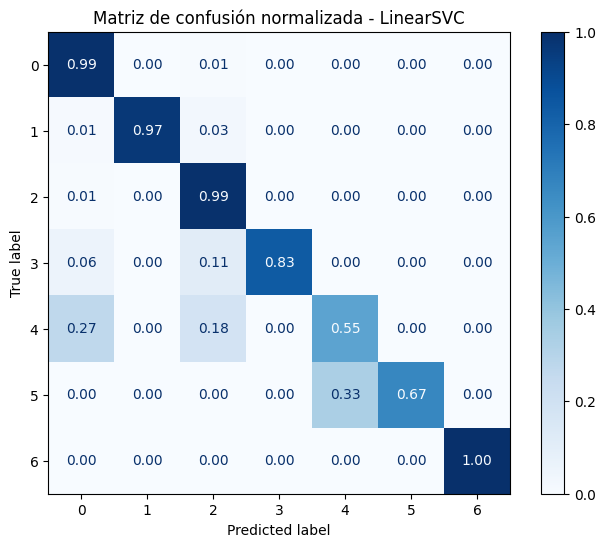

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# Entrenar nuevamente el mejor modelo
best_model = LinearSVC(random_state=42)
best_model.fit(X_train, y_train)

# Predicciones
y_pred = best_model.predict(X_test)

# Reporte por clase
print(classification_report(y_test, y_pred))

# Matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=ax, values_format=".2f", colorbar=True)
plt.title("Matriz de confusión normalizada - LinearSVC")
plt.show()

La matriz de confusión normalizada muestra que el modelo LinearSVC clasifica correctamente la mayoría de las observaciones en las clases 0, 1, 2 y 6.  
Sin embargo, el desempeño disminuye en las clases 3, 4 y 5, donde se observan confusiones entre categorías cercanas.  
Esto sugiere que el modelo captura bien los patrones más frecuentes, pero todavía presenta dificultades para separar clases menos representadas o más similares entre sí.

## Ajuste de modelos con balanceo de clases

Debido al desbalance observado entre las clases BI-RADS, se evaluó una segunda configuración de los modelos basada en ponderación automática de clases.  
Para ello, se utilizó el parámetro `class_weight="balanced"`, que asigna mayor peso a las clases menos frecuentes durante el entrenamiento.

Este ajuste permite analizar si el rendimiento mejora en categorías minoritarias sin modificar directamente la distribución de los datos.  
La comparación se realizará utilizando accuracy, Macro F1 y Weighted F1.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

balanced_models = {
    "LinearSVC balanced": LinearSVC(class_weight="balanced", random_state=42),
    "Logistic Regression balanced": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )
}

balanced_results = []

for name, model in balanced_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    balanced_results.append({
        "Modelo": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


LinearSVC balanced
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       193
           1       0.99      0.98      0.99       119
           2       1.00      0.99      0.99       527
           3       0.85      0.94      0.89        18
           4       1.00      0.55      0.71        11
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         1

    accuracy                           0.98       872
   macro avg       0.97      0.92      0.94       872
weighted avg       0.98      0.98      0.98       872


Logistic Regression balanced
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       193
           1       0.99      0.97      0.98       119
           2       0.99      0.94      0.97       527
           3       0.40      1.00      0.57        18
           4       0.58      0.64      0.61        11
           5       1.00     

In [19]:
balanced_results_df = pd.DataFrame(balanced_results)

comparison_df = pd.concat([results_df, balanced_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values(by="Macro F1", ascending=False)

comparison_df

,Modelo,Accuracy,Macro F1,Weighted F1
3,LinearSVC balanced,0.982798,0.936657,0.982161
0,LinearSVC,0.979358,0.899669,0.978422
4,Logistic Regression balanced,0.947248,0.821570,0.953769
1,Logistic Regression,0.957569,0.522278,0.949181
2,MultinomialNB,0.883028,0.416929,0.870113


## Resultados con balanceo de clases

La incorporación de `class_weight="balanced"` mejoró el rendimiento del modelo LinearSVC, alcanzando un accuracy de 0.983 y un Macro F1 de 0.937.  
Este resultado supera al LinearSVC original, por lo que la versión balanceada se selecciona como el mejor baseline clásico.

En Logistic Regression también se observó una mejora notable en Macro F1 respecto de la versión sin balanceo, aunque el rendimiento general siguió siendo inferior al de LinearSVC.  
Por tanto, el mejor modelo para esta etapa es LinearSVC con balanceo de clases.

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       193
           1       0.99      0.98      0.99       119
           2       1.00      0.99      0.99       527
           3       0.85      0.94      0.89        18
           4       1.00      0.55      0.71        11
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         1

    accuracy                           0.98       872
   macro avg       0.97      0.92      0.94       872
weighted avg       0.98      0.98      0.98       872



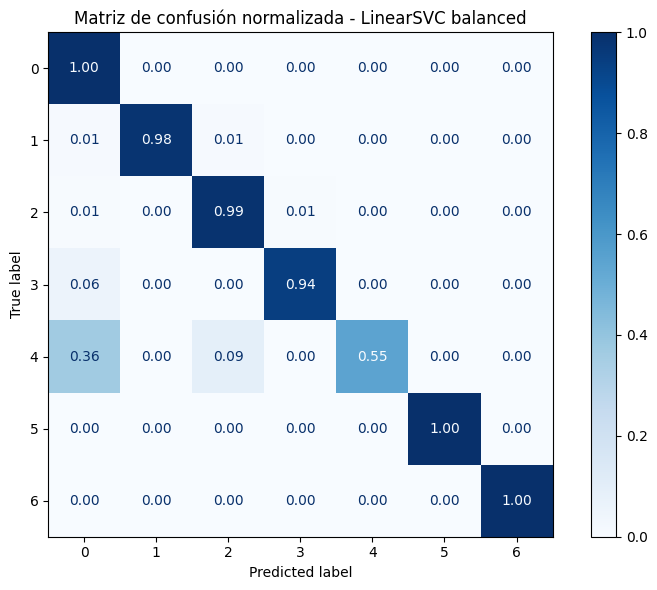

In [20]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Entrenamos el mejor modelo encontrado
best_model = LinearSVC(class_weight="balanced", random_state=42)
best_model.fit(X_train, y_train)

# Generamos predicciones sobre el conjunto de prueba
y_pred_best = best_model.predict(X_test)

# Mostramos el reporte de clasificación
print(classification_report(y_test, y_pred_best))

# Calculamos la matriz de confusión normalizada por fila
cm = confusion_matrix(y_test, y_pred_best, normalize="true")

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(cmap="Blues", ax=ax, values_format=".2f", colorbar=True)

plt.title("Matriz de confusión normalizada - LinearSVC balanced")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## Verificación adicional del Linear SVC balanced

Para confirmar la solidez del modelo, se realizó una validación adicional mediante validación cruzada estratificada y revisión de la matriz de confusión.  
Los resultados muestran un desempeño alto y consistente, aunque inferior al valor inicial observado en un único split de evaluación.

La matriz de confusión evidencia un buen comportamiento en las clases mayoritarias, mientras que las clases minoritarias siguen siendo las más difíciles de clasificar.

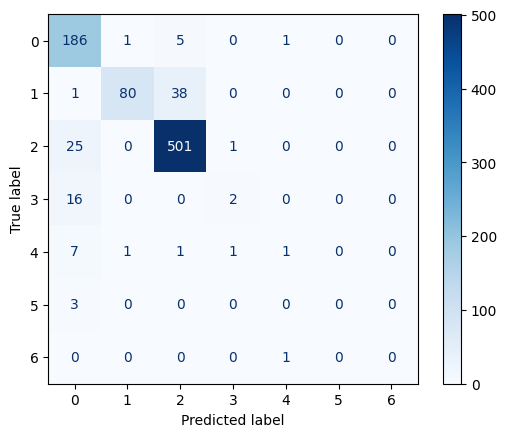

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9585    0.9585    0.9585       193
           1     0.9914    0.9664    0.9787       119
           2     0.9920    0.9431    0.9669       527
           3     0.4000    1.0000    0.5714        18
           4     0.5833    0.6364    0.6087        11
           5     1.0000    1.0000    1.0000         3
           6     0.5000    1.0000    0.6667         1

    accuracy                         0.9472       872
   macro avg     0.7750    0.9292    0.8216       872
weighted avg     0.9666    0.9472    0.9538       872



In [34]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

pipe = make_pipeline(
    TfidfVectorizer(),
    LinearSVC(class_weight='balanced')
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipe,
    train_df["text"],
    train_df["label"],
    cv=cv,
    scoring={"macro_f1": make_scorer(f1_score, average="macro")},
    return_train_score=True
)

scores["test_macro_f1"].mean(), scores["test_macro_f1"].std()

/Users/sebas/Library/CloudStorage/OneDrive-postgrado.uv.cl/Proyectos_Doc/proyecto-ia-mamografia/.venv/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


(np.float64(0.7369334938256829), np.float64(0.07034793058634997))

## Interpretación de la validación adicional

El rendimiento del Linear SVC balanced sigue siendo competitivo, pero la validación cruzada sugiere que el resultado inicial era algo optimista.  
Por esta razón, el desempeño real del modelo debe interpretarse a partir de la combinación de validación cruzada, matriz de confusión y reporte por clase, no solo de un único conjunto de prueba.

## Conclusión

El modelo **LinearSVC balanced** presentó el mejor desempeño entre los clasificadores evaluados en esta etapa.  
La matriz de confusión normalizada muestra que la mayoría de las predicciones se concentran en la diagonal principal, lo que indica una alta proporción de clasificaciones correctas en casi todas las clases.

Se observaron aciertos casi perfectos en las clases 0, 2, 5 y 6, además de un rendimiento alto en las clases 1 y 3.  
La principal dificultad persistió en la clase 4, donde parte de los casos fue confundida principalmente con las clases 0 y 2.

En conjunto, estos resultados confirman que el uso de `class_weight="balanced"` mejoró el comportamiento del modelo en un escenario multiclase desbalanceado.  
Por lo tanto, **LinearSVC balanced** se selecciona como el mejor baseline clásico y será utilizado como referencia para la comparación con modelos más avanzados en la siguiente etapa del proyecto.